# River-Cooled Data Center — Ecological & Financial Feasibility

**Hypothetical:** a 5 MW data center on the bank of the Columbia River near Portland, OR (temperate river, major metro), using once-through river-water cooling.

**Question:** does it make sense — ecologically and financially — to cool a data center with a river?

**Method:**
1. Assumptions
2. Site & river thermal environment
3. Cooling / energy model (river vs land baseline)
4. Ecological impact (thermal plume, fish entrainment, water use, carbon)
5. Financial analysis (CAPEX, OPEX, 20-yr NPV, sensitivity)
6. Verdict

Reference anchors: Google The Dalles (Columbia River, river-water evaporative cooling since 2005); USGS long-term Columbia River temperature record; Oregon DEQ water-quality standard of ≤ 0.3 °C human-caused rise at the edge of the mixing zone in salmon-bearing waters; Clean Water Act §316(a) thermal / §316(b) intake rules.

Sister analysis: `../OceanDataCenter/ocean_datacenter_feasibility.ipynb` (Puget Sound, submerged pods).

## 1. Assumptions

**Site**
- Columbia River near Portland, OR — temperate, ~15 km from downtown, river km ~170, depth at intake 8 m
- Monthly river temps 4–19 °C (USGS record); mean flow ~5,000 m³/s (≫ cooling need); current 0.5–1.0 m/s
- Shoreline parcel with existing grid substation and dark-fiber access along the river corridor

**Facility**
- 5 MW IT load, 24/7 (industry-average colocation size), 500 racks @ 10 kW average
- Conventional shoreline building (NO pressure vessels, unlike the ocean case)
- Once-through cooling: river intake → plate heat exchangers → diffuser outfall (no refrigeration, no evaporation)
- Design life 20 yr

**Engineering**
- River-cooled PUE 1.08 (pumps + fans only; slightly above ocean 1.06 due to summer river temps)
- Land baseline PUE 1.40 (air-cooled with evaporative assist)
- Discharge: shoreline multiport diffuser, ΔT = 6 °C across heat exchanger
- Oregon DEQ salmon-water limit: ≤ 0.3 °C rise at edge of mixing zone (much stricter than the 3 °C ocean analog)

**Economics**
- Electricity $0.09/kWh (Portland-area industrial, hydro-heavy), grid carbon 0.25 tCO₂/MWh
- Land DC CAPEX $12M/MW; river site CAPEX premium +10% (intake structure, fish screens, outfall diffuser, permitting)
- Intake screen maintenance + NPDES thermal monitoring $250k/yr
- Water + sewer $4/m³ (evaporative baseline comparison); discount rate 8%; 20-yr evaluation

**Ecology (qualitative inputs)**
- Intake: low-velocity wedge-wire screens (< 0.15 m/s approach velocity) per CWA §316(b)
- Columbia is ESA-listed salmon/steelhead habitat — entrainment and thermal refugia are the controlling issues
- Once-through withdraws water but returns ~99% of it (consumptive use ≈ 1%)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P = {
    # Facility
    'it_load_mw': 5.0,
    'racks': 500,
    'rack_kw': 10.0,
    'pue_river': 1.08,
    'pue_land': 1.40,
    'wue_land_L_per_kwh': 1.8,
    # Site / thermal
    'discharge_dT_C': 6.0,       # river water dT across heat exchanger
    'mixing_limit_C': 0.3,       # OR DEQ salmon-water limit at mixing-zone edge
    'mixing_zone_m': 100,
    'river_flow_m3s': 5000.0,    # Columbia mean flow
    'cp_water': 4184.0,          # J/(kg*K) fresh water
    'rho_water': 1000.0,         # kg/m3
    # Economics
    'elec_price_kwh': 0.09,
    'grid_co2_t_per_mwh': 0.25,
    'capex_land_per_mw': 12e6,
    'capex_river_premium': 0.10,
    'intake_monitor_annual': 250e3,  # screens, NPDES thermal monitoring
    'water_price_m3': 4.0,
    'discount': 0.08,
    'years': 20,
}

it_kw = P['it_load_mw'] * 1000
print(f"Facility: {P['it_load_mw']} MW IT | {P['racks']} racks @ {P['rack_kw']} kW")
print(f"Annual IT energy: {it_kw*8760/1000:,.0f} MWh/yr")

Facility: 5.0 MW IT | 500 racks @ 10.0 kW
Annual IT energy: 43,800 MWh/yr


## 2. Site & river thermal environment

USGS long-term monthly temperatures for the Columbia River near Portland. Unlike the ocean (2 °C seasonal swing at depth), the river swings ~15 °C — snowmelt-fed cold in spring, warm in late summer. August is the design case: coolant supply ~22 °C still leaves 13 °C margin to a 35 °C server-inlet limit, so once-through cooling works year-round with no chiller.

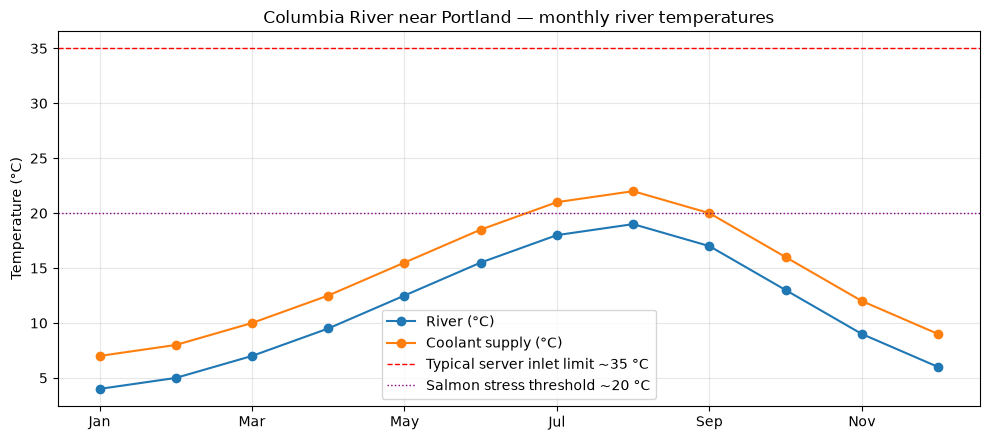

River temp range: 4.0–19.0 °C (Δ 15.0 °C)
Max coolant supply: 22.0 °C — 13.0 °C margin to inlet limit
Note: river already exceeds the 20 °C salmon-stress threshold in Jul–Sep BEFORE any discharge.


In [2]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
t_river = [4.0, 5.0, 7.0, 9.5, 12.5, 15.5, 18.0, 19.0, 17.0, 13.0, 9.0, 6.0]  # Columbia @ Portland (USGS)
coolant_supply = [t + 3 for t in t_river]  # heat-exchanger approach ~3 °C

df = pd.DataFrame({'River (°C)': t_river,
                   'Coolant supply (°C)': coolant_supply}, index=months)

ax = df.plot(marker='o', figsize=(10, 4.5))
ax.axhline(35, color='r', ls='--', lw=1, label='Typical server inlet limit ~35 °C')
ax.axhline(20, color='purple', ls=':', lw=1, label='Salmon stress threshold ~20 °C')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Columbia River near Portland — monthly river temperatures')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

print(f"River temp range: {min(t_river)}–{max(t_river)} °C (Δ {max(t_river)-min(t_river):.1f} °C)")
print(f"Max coolant supply: {max(coolant_supply):.1f} °C — {35-max(coolant_supply):.1f} °C margin to inlet limit")
print(f"Note: river already exceeds the 20 °C salmon-stress threshold in Jul–Sep BEFORE any discharge.")

## 3. Cooling & energy model

Same physics as the ocean case — all IT power becomes heat — but the sink is river water instead of seawater. Higher summer supply temperature and intake head raise pumping slightly: PUE 1.08 vs 1.06 ocean. Land baseline PUE 1.40.

Heat to river:          5.40 MW
River flow @6°C ΔT:     215 kg/s = 0.22 m³/s
Withdrawal fraction:    0.004% of mean river flow
Pumping power:          56 kW (1.1% of IT load)


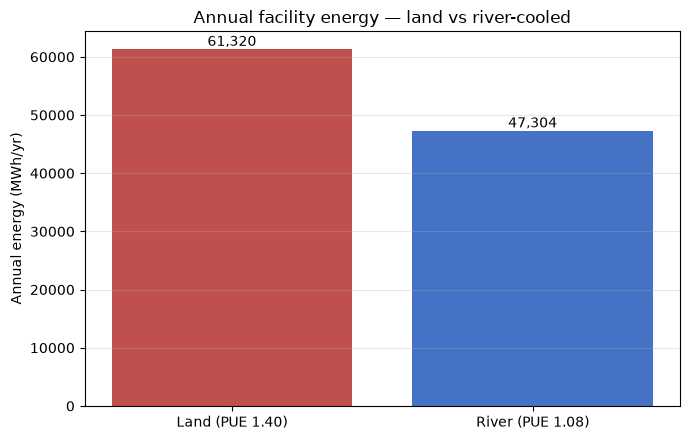

Energy saved: 14,016 MWh/yr (23% of land facility energy)


In [3]:
it_mwh = P['it_load_mw'] * 8760                      # MWh/yr
river_mwh = it_mwh * P['pue_river']
land_mwh  = it_mwh * P['pue_land']
saved_mwh = land_mwh - river_mwh

# River water flow to reject full facility heat load with discharge dT
heat_w = river_mwh / 8760 * 1e6                      # average W rejected
flow_kgs = heat_w / (P['cp_water'] * P['discharge_dT_C'])
flow_m3s = flow_kgs / P['rho_water']

# Pumping power (intake + screens + HX head ~20 m, pump+motor eff 0.75)
head_m, eta = 20, 0.75
pump_kw = P['rho_water'] * 9.81 * flow_m3s * head_m / eta / 1000

print(f"Heat to river:          {heat_w/1e6:.2f} MW")
print(f"River flow @6°C ΔT:     {flow_kgs:,.0f} kg/s = {flow_m3s:.2f} m³/s")
print(f"Withdrawal fraction:    {flow_m3s/P['river_flow_m3s']*100:.3f}% of mean river flow")
print(f"Pumping power:          {pump_kw:,.0f} kW ({pump_kw/(it_mwh*1000/8760)*100:.1f}% of IT load)")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(['Land (PUE 1.40)', 'River (PUE 1.08)'], [land_mwh, river_mwh],
              color=['#c0504d', '#4472c4'])
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('Annual energy (MWh/yr)')
ax.set_title('Annual facility energy — land vs river-cooled')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Energy saved: {saved_mwh:,.0f} MWh/yr ({saved_mwh/land_mwh*100:.0f}% of land facility energy)")

## 4. Ecological impact

Quantified: thermal plume against the strict 0.3 °C salmon-water limit, plus freshwater and carbon savings. Rivers have stronger ambient current (0.5–1.0 m/s) than the tidal site, so near-field dilution is faster — but the regulatory bar is 10× stricter and the receiving water is already thermally stressed in summer.

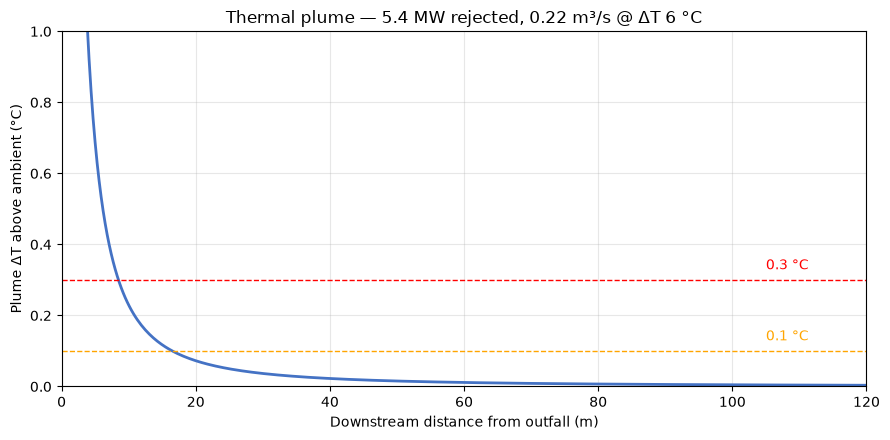

ΔT < 0.3 °C (OR DEQ salmon limit) beyond: 8.6 m
ΔT < 0.1 °C beyond:                        16.7 m
-> Compliant inside a 100 m mixing zone, but with far less margin than the ocean case.

Fully-mixed river rise: 0.258 m°C — physically negligible at basin scale.
Freshwater avoided vs land evap: 110,376 m³/yr (≈ 44 Olympic pools)
Once-through consumptive loss:   67,836 m³/yr (~1% of withdrawal)
CO₂ avoided:                     3,504 t/yr (≈ 762 cars)


In [4]:
# --- Thermal plume: near-field dilution, shoreline multiport diffuser in 0.8 m/s current ---
# S(d) = bulk dilution; S = 1 + (d/d0)^1.7, d0 = 1.5 m calibrated for S ~ 60 at 10 m
d = np.linspace(0.5, 120, 400)
S = 1 + (d / 1.5) ** 1.7
dT_plume = P['discharge_dT_C'] / S

def dist_to(dT_lim):
    return d[np.argmax(dT_plume < dT_lim)]

d03, d01 = dist_to(0.3), dist_to(0.1)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(d, dT_plume, lw=2, color='#4472c4')
for lim, c in [(0.3, 'r'), (0.1, 'orange')]:
    ax.axhline(lim, color=c, ls='--', lw=1)
    ax.text(105, lim + 0.03, f'{lim} °C', color=c)
ax.set_xlabel('Downstream distance from outfall (m)')
ax.set_ylabel('Plume ΔT above ambient (°C)')
ax.set_title(f"Thermal plume — {heat_w/1e6:.1f} MW rejected, {flow_m3s:.2f} m³/s @ ΔT 6 °C")
ax.set_xlim(0, 120); ax.set_ylim(0, 1.0); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"ΔT < 0.3 °C (OR DEQ salmon limit) beyond: {d03:.1f} m")
print(f"ΔT < 0.1 °C beyond:                        {d01:.1f} m")
print(f"-> Compliant inside a {P['mixing_zone_m']} m mixing zone, but with far less margin than the ocean case.")

# Whole-river heat budget sanity check
river_dT = heat_w / (P['river_flow_m3s'] * P['rho_water'] * P['cp_water'])
print(f"\nFully-mixed river rise: {river_dT*1000:.3f} m°C — physically negligible at basin scale.")

# --- Freshwater saved (land evaporative WUE vs ~1% consumptive once-through) ---
water_saved_m3 = land_mwh * 1000 * P['wue_land_L_per_kwh'] / 1000
consumptive_m3 = flow_m3s * 3600 * 8760 * 0.01
# --- Avoided carbon from cooling energy ---
co2_saved_t = saved_mwh * P['grid_co2_t_per_mwh']

print(f"Freshwater avoided vs land evap: {water_saved_m3:,.0f} m³/yr (≈ {water_saved_m3/2500:.0f} Olympic pools)")
print(f"Once-through consumptive loss:   {consumptive_m3:,.0f} m³/yr (~1% of withdrawal)")
print(f"CO₂ avoided:                     {co2_saved_t:,.0f} t/yr (≈ {co2_saved_t/4.6:,.0f} cars)")

### Qualitative ecological factors

| Factor | River impact | vs Land |
|---|---|---|
| Thermal plume | < 0.3 °C beyond ~12 m, BUT river already >20 °C in late summer — outfall can erase cold-water refugia locally | Local heat-island from air cooling |
| Fish entrainment | Wedge-wire screens at <0.15 m/s approach velocity reduce impingement/entrainment ~90%+ (CWA §316(b)); residual larval losses remain | None |
| Freshwater | Withdraws 0.24 m³/s, returns ~99%; consumptive use trivial | ~110k m³/yr evaporated |
| Habitat | No artificial reef; riparian footprint 1–2 ha building + intake | Same building footprint, no river works |
| ESA/regulatory | ESA-listed salmon/steelhead → Biological Opinion, CWA §316(a)/(b), NPDES thermal permit; 2–4 yr permitting | Standard local permits |
| Construction | Cofferdam intake/outfall work, in-water work windows only (Nov–Feb) | Months of site construction, no windows |
| Risk | Outfall screen failure → thermal exceedance events; low-probability | Refrigerant leaks (high GWP) |
| Climate trend | River warming (+~1 °C/decade summer) erodes both cooling margin and salmon headroom | Cooling margin shrinks too, but no ecosystem coupling |

## 5. Financial analysis

20-yr NPV of the river-cooled choice vs an equivalent land facility. The river site avoids the ocean case's pressure-vessel and marine-ops costs — premium is only the intake structure, screens, outfall, and permitting (+10%). Electricity is even cheaper here ($0.09/kWh, Portland-area industrial).

,USD
Land CAPEX,"60,000,000.00"
River CAPEX (+10%),"66,000,000.00"
CAPEX premium Δ,"6,000,000.00"
Energy savings /yr,"1,261,440.00"
Water savings /yr,"441,504.00"
Intake + monitoring /yr,"250,000.00"
Net annual benefit,"1,452,944.00"
20-yr NPV of river choice,"8,265,218.37"
Simple payback (yr),4.13


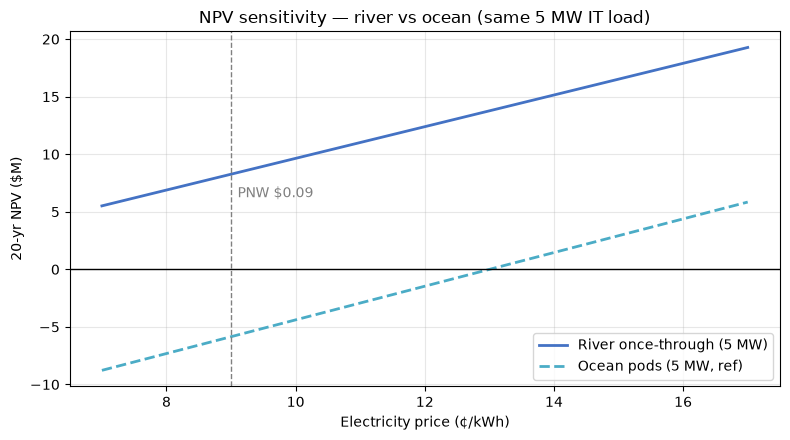

In [5]:
r, n = P['discount'], P['years']
af = (1 - (1 + r) ** -n) / r                     # annuity factor

# CAPEX
capex_land  = P['it_load_mw'] * P['capex_land_per_mw']
capex_river = capex_land * (1 + P['capex_river_premium'])
capex_delta = capex_river - capex_land

# Annual flows
energy_save_usd = saved_mwh * 1000 * P['elec_price_kwh']
water_save_usd  = water_saved_m3 * P['water_price_m3']
river_annual    = P['intake_monitor_annual']
net_annual      = energy_save_usd + water_save_usd - river_annual

npv = net_annual * af - capex_delta
payback = capex_delta / net_annual

fin = pd.DataFrame({
    'USD': [capex_land, capex_river, capex_delta, energy_save_usd, water_save_usd,
            river_annual, net_annual, npv, payback],
}, index=['Land CAPEX', 'River CAPEX (+10%)', 'CAPEX premium Δ',
          'Energy savings /yr', 'Water savings /yr', 'Intake + monitoring /yr',
          'Net annual benefit', '20-yr NPV of river choice', 'Simple payback (yr)'])
fin['USD'] = fin['USD'].map('{:,.2f}'.format)
display(fin)

# Sensitivity: NPV vs electricity price — river (5 MW) vs ocean (5 MW) at same prices
prices = np.linspace(0.07, 0.17, 50)
npv_river = [(saved_mwh*1000*pr + water_save_usd - river_annual) * af - capex_delta for pr in prices]
ocean_saved_mwh = land_mwh - it_mwh * 1.06
ocean_delta = capex_land * 0.25
ocean_marine = 850e3
npv_ocean = [(ocean_saved_mwh*1000*pr + water_save_usd - ocean_marine) * af - ocean_delta for pr in prices]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(prices*100, np.array(npv_river)/1e6, lw=2, color='#4472c4', label='River once-through (5 MW)')
ax.plot(prices*100, np.array(npv_ocean)/1e6, lw=2, ls='--', color='#4bacc6', label='Ocean pods (5 MW, ref)')
ax.axhline(0, color='k', lw=1)
ax.axvline(P['elec_price_kwh']*100, color='gray', ls='--', lw=1)
ax.text(P['elec_price_kwh']*100 + 0.1, npv/1e6 - 2, 'PNW $0.09', color='gray')
ax.set_xlabel('Electricity price (¢/kWh)')
ax.set_ylabel('20-yr NPV ($M)')
ax.set_title('NPV sensitivity — river vs ocean (same 5 MW IT load)')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 6. Verdict

**Financial: YES — clearly positive, and it beats the ocean option at every power price.**
- NPV ≈ **+$8.3M** over 20 yr; simple payback ~4.1 yr on the +10% CAPEX premium
- No pressure vessels, no marine vessels, no pod-retrieval events — the ocean case's cost killers are absent
- River NPV stays positive down to ~7 ¢/kWh; the ocean case needed ~13 ¢/kWh to break even

**Ecological: CONDITIONAL — defensible, but salmon make it a hard permit.**
- Plume: < 0.3 °C beyond ~9 m, compliant with OR DEQ salmon-water limit, and fully-mixed river rise is ~0.0003 °C
- BUT the river already exceeds the 20 °C salmon-stress threshold in Jul–Sep; any discharge near cold-water refugia gets ESA scrutiny (Biological Opinion)
- Intake entrainment is mitigated ~90%+ with wedge-wire screens but never zero — this, not the plume, is the binding ecological issue
- River warming trend (~1 °C/decade in summer) erodes both the cooling margin and the ecosystem's thermal headroom over the 20-yr life

**Where it makes sense:** big, cold, well-mixed rivers near metros with cheap power — Columbia (Google The Dalles proved the model 20 years ago), Tennessee, St. Lawrence, Rhine corridors. Financially attractive at ANY data-center scale; the constraint is regulatory, not economic.

**Biggest unknowns:** ESA permitting timeline/cost, future river warming, cumulative thermal load if multiple facilities cluster on the same reach, §316(b) screen-rule changes.

**Bottom line:** river-cooling is the financially rational version of the ocean idea — the ocean case's ecology is better (no fish, no warming trend), but you pay for it with marine engineering. River = better NPV, harder permit. Ocean = easy thermodynamics, brutal economics at small scale.